# Training Model Bi-LSTM Dataset Pidana 200

## Import Requirement

In [6]:
from __future__ import absolute_import, division, print_function, unicode_literals

! pip -q install git+https://www.github.com/keras-team/keras-contrib.git sklearn-crfsuite

import tensorflow as tf
import keras

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

  error: subprocess-exited-with-error
  
  × git clone --filter=blob:none --quiet https://www.github.com/keras-team/keras-contrib.git /tmp/pip-req-build-q2k7290_ did not run successfully.
  │ exit code: 128
  ╰─> [1 lines of output]
      fatal: unable to access 'https://www.github.com/keras-team/keras-contrib.git/': Could not resolve host: www.github.com
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× git clone --filter=blob:none --quiet https://www.github.com/keras-team/keras-contrib.git /tmp/pip-req-build-q2k7290_ did not run successfully.
│ exit code: 128
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [7]:
print(tf.__version__)

2.13.0


## Set Parameter Training Model

In [8]:
BATCH_SIZE = 64  # Number of examples used in each iteration
EPOCHS = 100  # Number of passes through entire dataset
MAX_LEN = 10  # Max length of review (in words)
EMBEDDING = 100  # Dimension of word embedding vector

## Import Dataset Pidana 200

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

data = pd.read_csv("/kaggle/input/dataset-pos-pidana-baru/DatasetPos-Pidana200.csv", encoding="latin1")
# data = pd.read_csv("/kaggle/input/dataset-pidana-baru/Dataset-Pidana200 (1).csv")

data['word'] = data['word'].str.lower()
data['word'] = data['word'].replace(to_replace ='\d+', value = '<\g<0>>', regex = True).replace(to_replace ='[0-9]', value = 'X', regex = True)
data = data.fillna(method="ffill")

In [10]:
data

,doc,sentence,word,pos,prev,next,tag
0,doc: 1,sentence: 000001,putusan,NOUN,.,nomor,O
1,doc: 1,sentence: 000001,nomor,NOUN,putusan,325,O
2,doc: 1,sentence: 000001,<XXX>,NUM,nomor,/,B_VERN
3,doc: 1,sentence: 000001,/,PUNCT,325,pid,I_VERN
4,doc: 1,sentence: 000001,pid,PROPN,/,.,I_VERN
...,...,...,...,...,...,...,...
1235502,doc: 200,sentence: 023610,",",PUNCT,pengganti,budi,O
1235503,doc: 200,sentence: 023610,budi,NOUN,",",ariyanto,O
1235504,doc: 200,sentence: 023610,ariyanto,PROPN,budi,",",O
1235505,doc: 200,sentence: 023610,",",PUNCT,ariyanto,sh,O


In [11]:
data.groupby('tag').count()

,doc,sentence,word,pos,prev,next
tag,,,,,,
B_ADVO,51,51,51,51,51,51
B_ARTV,192,192,192,192,192,192
B_CRIA,175,175,175,175,175,175
B_DEFN,269,269,269,269,269,269
B_JUDG,394,394,394,394,394,394
B_JUDP,203,203,203,203,203,203
B_PENA,256,256,256,256,256,256
B_PROS,198,198,198,198,198,198
B_PUNI,242,242,242,242,242,242


In [12]:
data = data[data['pos'] != 'PUNCT']
data = data[data['pos'] != 'PRON']
data = data[data['pos'] != 'CCONJ']
data = data[data['pos'] != 'ADP']
data = data[data['pos'] != 'AUX']
data = data[data['pos'] != 'DET']
data = data[data['pos'] != 'ADV> Menimbang <VERB']
data = data[data['pos'] != ' <SYM']
data = data[data['pos'] != 'PROPN> LEL <PROPN']
data = data[data['pos'] != 'PROPN> _ <PROPN> Er <PROPN']
data = data[data['pos'] != 'PROPN> _ <PUNCT> IV <NUM']
data = data[data['pos'] != 'PROPN> _ <PROPN> Ep <PROPN']

In [13]:
# data[data['pos'] == 'PRON']

In [14]:
# data['pos'].unique()

In [15]:
# data['tag'] = data['tag'].apply(lambda x: [x])
# # Gabungkan tags dalam sentence yang sama dan hapus sentence yang hanya berisi tag 'O'
# df_combined = (
#     data.groupby(['doc', 'sentence'])['tag']
#     .agg(lambda x: sum(x, []))
#     .apply(lambda tags: tags if any(tag != 'O' for tag in tags) else [])
#     .reset_index(name='tag')
# )

# # Hapus baris yang tidak memiliki tag atau memiliki tag kosong
# df_combined = df_combined[df_combined['tag'].apply(lambda x: bool(x))]

# # Buat DataFrame baru hanya berisi baris yang sesuai dengan df_combined
# filtered_df = data[data['sentence'].isin(df_combined['sentence'])]

# # Pisahkan df_combined per tag dan isi sentence berdasarkan tag yang dipisah tadi
# result_rows = []
# for index, row in filtered_df.iterrows():
#     for tag in row['tag']:
#         result_rows.append({
#             'doc': row['doc'],
#             'sentence': row['sentence'],
#             'word': row['word'],
# #             'pos': row['pos'],
#             'prev': row['prev'],
#             'next': row['next'],
#             'tag': tag
#         })

# # Tampilkan dataframe setelah penggabungan, penghapusan, pemisahan kembali tags, dan pengisian kolom 'sentence'
# data = pd.DataFrame(result_rows)

# # Tampilkan dataframe hasil
# data

In [16]:
data.groupby('tag').count()

,doc,sentence,word,pos,prev,next
tag,,,,,,
B_ADVO,43,43,43,43,43,43
B_ARTV,192,192,192,192,192,192
B_CRIA,175,175,175,175,175,175
B_DEFN,213,213,213,213,213,213
B_JUDG,327,327,327,327,327,327
B_JUDP,167,167,167,167,167,167
B_PENA,256,256,256,256,256,256
B_PROS,174,174,174,174,174,174
B_PUNI,239,239,239,239,239,239


## Menambahkan token untuk Padding data

In [17]:
words = list(set(data["word"].values))
words.append("ENDPAD")
n_words = len(words)
n_words

15812

In [18]:
tags = list(set(data["tag"].values))
n_tags = len(tags)
n_tags

25

## Mengambil Data berdasarkan Dokumen dan Sentence

In [19]:
class SentenceGetter(object):

    def __init__(self, data):
        self.n_sent = 1
        self.data = data
        self.empty = False
        agg_func = lambda s: [(w, t) for w, t in zip(s["word"].values.tolist(),
                                                           s["tag"].values.tolist())]
        self.grouped = self.data.groupby("sentence").apply(agg_func)
        self.sentences = [s for s in self.grouped]

    def get_next(self):
        try:
            s = self.grouped[self.n_sent]
            self.n_sent += 1
            return s
        except:
            return None

class DocGetter(object):

    def __init__(self, data):
        self.n_doc = 1
        self.data = data
        self.empty = False
        agg_func = lambda s: [(w, t) for w, t in zip(s["word"].values.tolist(),
                                                           s["tag"].values.tolist())]
        self.grouped = self.data.groupby("doc").apply(agg_func)
        self.docs = [s for s in self.grouped]

    def get_next(self):
        try:
            d = self.grouped[self.n_doc]
            self.n_doc += 1
            return d
        except:
            return None

In [20]:
# getter = DocGetter(data)
# docs = getter.docs
getter = SentenceGetter(data)
sentences = getter.sentences

### Visualisasi panjang kalimat pada dataset berdasarkan sentence

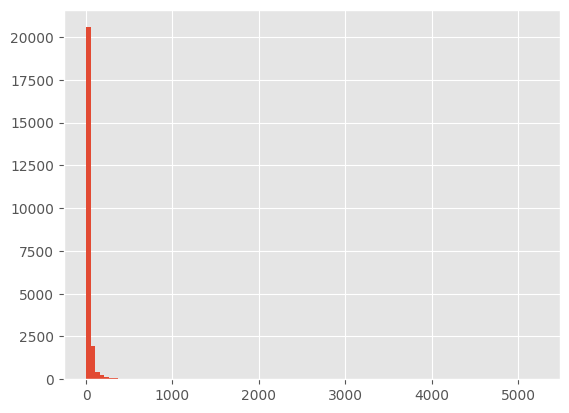

In [21]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")

plt.hist([len(s) for s in sentences], bins=100)
plt.show()

## Membentuk Dictionary

In [22]:
# Vocabulary Key:word -> Value:token_index
# The first 2 entries are reserved for PAD and UNK
# word2idx = {w: i + 2 for i, w in enumerate(vocab)}
word2idx = {k: v + 2 for (k, v) in zip(words, range(len(words)))}
word2idx["UNK"] = 1 # Unknown words
word2idx["PAD"] = 0 # Padding

# Vocabulary Key:token_index -> Value:word
idx2word = {i: w for w, i in word2idx.items()}

# Vocabulary Key:Label/Tag -> Value:tag_index
# The first entry is reserved for PAD
tag2idx = {t: i+1 for i, t in enumerate(tags)}
tag2idx["PAD"] = 0

# Vocabulary Key:tag_index -> Value:Label/Tag
idx2tag = {i: w for w, i in tag2idx.items()}

## Spliting Dataset Training dan Testing

In [23]:
from tensorflow.keras.utils import pad_sequences

# Convert each sentence from list of Token to list of word_index
X = [[word2idx[w[0]] for w in s] for s in sentences]
# Padding each sentence to have the same lenght
X = pad_sequences(maxlen=MAX_LEN, sequences=X, padding="post", value=word2idx["PAD"])


# Convert Tag/Label to tag_index
y = [[tag2idx[w[1]] for w in s] for s in sentences]
# Padding each sentence to have the same lenght
y = pad_sequences(maxlen=MAX_LEN, sequences=y, padding="post", value=tag2idx["PAD"])

from keras.utils import to_categorical
# One-Hot encode
y = [to_categorical(i, num_classes=n_tags+1) for i in y]

from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.1, shuffle=False)
X_tr.shape, X_te.shape, np.array(y_tr).shape, np.array(y_te).shape

((21245, 10), (2361, 10), (21245, 10, 26), (2361, 10, 26))

## Cek konversi dataset ke bentuk indeks

In [24]:
print("The word indonesia is identified by the index: {}".format(word2idx["indonesia"]))
print("The labels B_ADVO is identified by the index: {}".format(tag2idx["B_ADVO"]))
i=2
print('Raw Sample  : ', ' '.join([w for w, t in getter.sentences[i]]))
print('Text2vec    : ', ' '.join(['{}'.format(word2idx[w]) for w, t in getter.sentences[i]]))
print('Text2vec PAD: ', ' '.join(['{}'.format(w) for w in X[i]]))
print('Raw Label   : ', ' '.join([t for w, t in getter.sentences[i]]))
print('Tag2vec     : ', ' '.join(['{}'.format(tag2idx[t]) for w, t in getter.sentences[i]]))

The word indonesia is identified by the index: 14342
The labels B_ADVO is identified by the index: 16
Raw Sample  :  umur tanggal lahir <XX> tahun <X> maret <XXXX>
Text2vec    :  2043 9844 592 4386 11038 5440 177 4642
Text2vec PAD:  2043 9844 592 4386 11038 5440 177 4642 0 0
Raw Label   :  O O O O O O O O
Tag2vec     :  2 2 2 2 2 2 2 2


In [25]:
! pip install tensorflow-addons

## Arsitektur Model

In [26]:
from keras import Model
from keras import optimizers
from keras.layers import Input, LSTM, Embedding, Dense, TimeDistributed, Dropout, Bidirectional, SpatialDropout1D
from tensorflow_addons.layers import CRF

input = Input(shape=(MAX_LEN,))

model = Embedding(input_dim=n_words, output_dim=EMBEDDING, input_length=MAX_LEN)(input)
model = Dropout(0.1)(model)
model = Bidirectional(LSTM(units=100, return_sequences=True, recurrent_dropout=0.1))(model)

out = TimeDistributed(Dense(n_tags+1, activation="softmax"))(model)  # softmax output layer

model = Model(input, out)

model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])

model.summary()

/opt/conda/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 10)]              0         
                                                                 
 embedding (Embedding)       (None, 10, 100)           1581200   
                                                                 
 dropout (Dropout)           (None, 10, 100)           0         
                                                                 
 bidirectional (Bidirection  (None, 10, 200)           160800    
 al)                                                             
                                                                 
 time_distributed (TimeDist  (None, 10, 26)            5226      
 ributed)                                                        
                                                                 
Total params: 1747226 (6.67 MB)
Trainable params: 1747226 (6.

In [27]:
history = model.fit(np.array(X_tr).astype(int),
                    np.array(y_tr).astype(int),
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_split=0.1,
                    verbose=1)

Epoch 1/100
299/299 [==============================] - 20s 45ms/step - loss: 0.2529 - accuracy: 0.9644 - val_loss: 0.0788 - val_accuracy: 0.9817
Epoch 2/100
299/299 [==============================] - 13s 42ms/step - loss: 0.0484 - accuracy: 0.9891 - val_loss: 0.0598 - val_accuracy: 0.9848
Epoch 3/100
299/299 [==============================] - 13s 42ms/step - loss: 0.0378 - accuracy: 0.9905 - val_loss: 0.0495 - val_accuracy: 0.9865
Epoch 4/100
299/299 [==============================] - 13s 45ms/step - loss: 0.0317 - accuracy: 0.9920 - val_loss: 0.0430 - val_accuracy: 0.9885
Epoch 5/100
299/299 [==============================] - 13s 42ms/step - loss: 0.0266 - accuracy: 0.9926 - val_loss: 0.0414 - val_accuracy: 0.9903
Epoch 6/100
299/299 [==============================] - 13s 45ms/step - loss: 0.0235 - accuracy: 0.9937 - val_loss: 0.0407 - val_accuracy: 0.9901
Epoch 7/100
299/299 [==============================] - 13s 43ms/step - loss: 0.0211 - accuracy: 0.9942 - val_loss: 0.0355 - val_ac

### Save Model

In [28]:
import torch

In [29]:
path = 'model-BiLSTM-Pidana200.pth'
torch.save(model, path)

### Visualisasi hasil training model

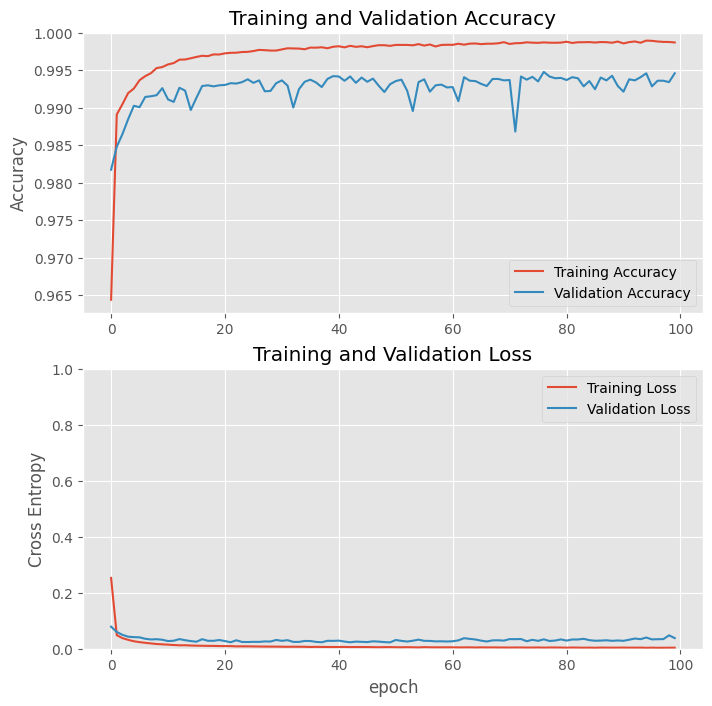

In [30]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

## Evaluasi

In [31]:
eve = model.predict(X_te)

74/74 [==============================] - 1s 7ms/step


In [32]:
y_pred = np.argmax(eve, axis=-1)
y_test_true = np.argmax(y_te, -1)

# Convert the index to tag
y_pred = [[idx2tag[i] for i in row] for row in y_pred]
y_test_true = [[idx2tag[i] for i in row] for row in y_test_true]

In [33]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

m = MultiLabelBinarizer().fit(y_test_true)
print("Precision Score: {}".format(precision_score(m.transform(y_test_true), m.transform(y_pred), average="macro")))
print("Recall Score   : {}".format(recall_score(m.transform(y_test_true), m.transform(y_pred), average="macro")))
print("F1-score Score : {}".format(f1_score(m.transform(y_test_true), m.transform(y_pred), average="macro")))

Precision Score: 0.46895107158488636
Recall Score   : 0.5073878337974083
F1-score Score : 0.4829316428419594


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [34]:
from sklearn.metrics import classification_report
def c_report(y_pred, y_true):
  # Menggabungkan elemen-elemen array menjadi satu list
  y_pred_flat = [item for sublist in y_pred for item in sublist]
  y_true_flat = [item for sublist in y_true for item in sublist]
  report = classification_report(y_pred_flat, y_true_flat)
  return report

In [35]:
report = c_report(y_pred, y_test_true)
print(report)

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

      B_ADVO       0.00      0.00      0.00         0
      B_ARTV       0.71      0.56      0.63         9
      B_CRIA       0.00      0.00      0.00         1
      B_DEFN       0.70      0.78      0.74         9
      B_JUDG       0.00      0.00      0.00         0
      B_JUDP       0.00      0.00      0.00         0
      B_PENA       0.57      0.67      0.62         6
      B_PROS       1.00      1.00      1.00         6
      B_PUNI       1.00      0.83      0.91        12
      B_TIMV       0.00      0.00      0.00         0
      I_ADVO       0.00      0.00      0.00         0
      I_ARTV       0.44      0.40      0.42        81
      I_CRIA       0.75      0.60      0.67         5
      I_DEFN       0.89      0.95      0.92        42
      I_JUDG       0.00      0.00      0.00         0
      I_JUDP       0.00      0.00      0.00         0
      I_PENA       0.50      0.76      0.60        41
      I_PROS       1.00    

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Confusion matriks

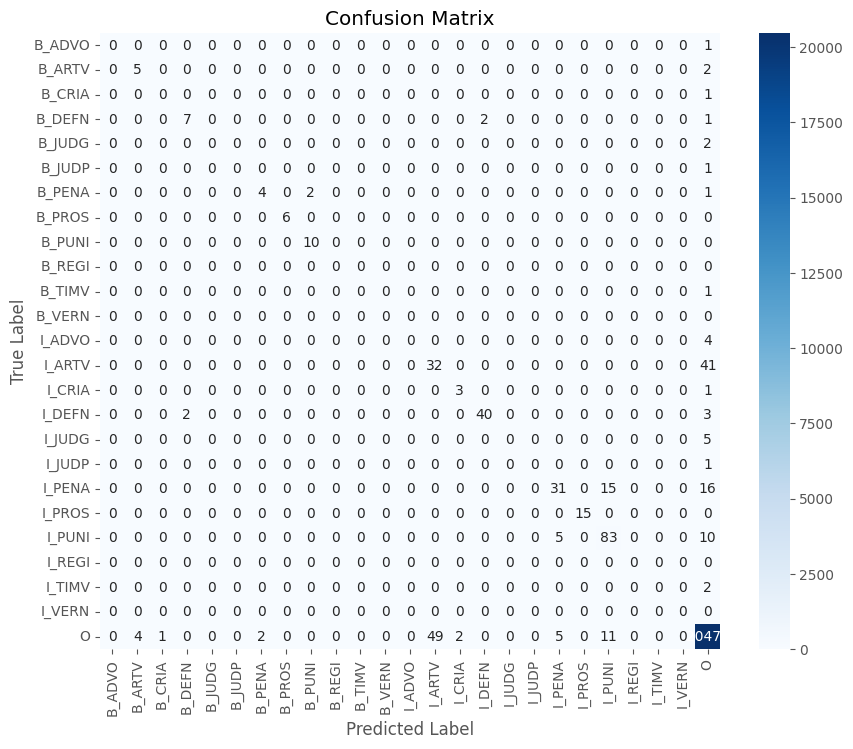

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Definisi class_names (sesuaikan dengan label yang sesuai dalam datasetmu)
class_names = ['B_ADVO', 'B_ARTV', 'B_CRIA', 'B_DEFN', 'B_JUDG', 'B_JUDP', 'B_PENA', 'B_PROS', 'B_PUNI', 'B_REGI', 'B_TIMV', 'B_VERN', 'I_ADVO', 'I_ARTV', 'I_CRIA', 'I_DEFN', 'I_JUDG', 'I_JUDP', 'I_PENA', 'I_PROS', 'I_PUNI', 'I_REGI', 'I_TIMV', 'I_VERN', 'O']

conf_mat = confusion_matrix([item for sublist in y_test_true for item in sublist],
                            [item for sublist in y_pred for item in sublist],
                            labels=class_names)
# Visualisasi confusion matrix menggunakan heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
